
Epoch 1/30
Generator loss: 1.1528, Discriminator loss: 0.9669


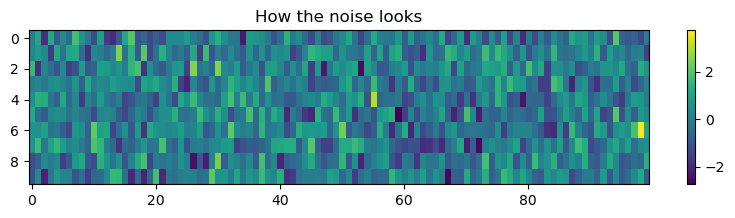

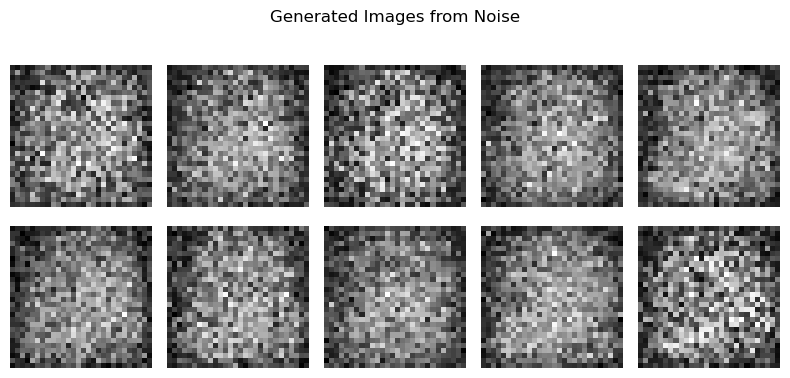


Epoch 2/30
Generator loss: 1.5066, Discriminator loss: 0.8446

Epoch 3/30
Generator loss: 1.6944, Discriminator loss: 0.9449

Epoch 4/30
Generator loss: 1.2942, Discriminator loss: 1.0603

Epoch 5/30
Generator loss: 1.4536, Discriminator loss: 1.0285

Epoch 6/30
Generator loss: 1.3822, Discriminator loss: 1.0179

Epoch 7/30
Generator loss: 1.1117, Discriminator loss: 1.1719

Epoch 8/30
Generator loss: 0.9668, Discriminator loss: 1.2317

Epoch 9/30
Generator loss: 1.0693, Discriminator loss: 1.1998

Epoch 10/30
Generator loss: 1.0123, Discriminator loss: 1.2380

Epoch 11/30
Generator loss: 0.9586, Discriminator loss: 1.2841


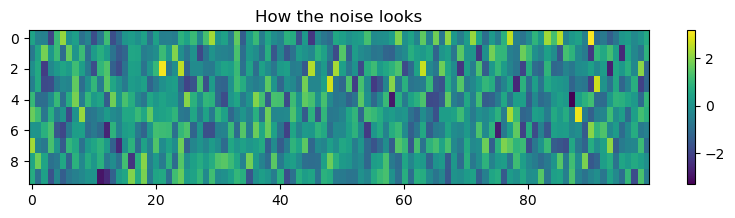

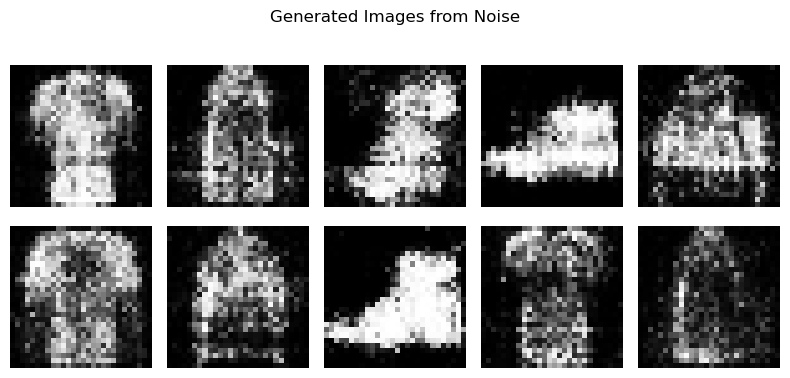


Epoch 12/30
Generator loss: 0.9840, Discriminator loss: 1.2606

Epoch 13/30
Generator loss: 0.9769, Discriminator loss: 1.2909

Epoch 14/30
Generator loss: 0.9919, Discriminator loss: 1.2765

Epoch 15/30
Generator loss: 0.9285, Discriminator loss: 1.3006

Epoch 16/30
Generator loss: 0.9609, Discriminator loss: 1.3556

Epoch 17/30
Generator loss: 0.9271, Discriminator loss: 1.2294

Epoch 18/30
Generator loss: 0.9220, Discriminator loss: 1.2979

Epoch 19/30
Generator loss: 0.9044, Discriminator loss: 1.2801

Epoch 20/30
Generator loss: 0.9194, Discriminator loss: 1.3180

Epoch 21/30
Generator loss: 0.9032, Discriminator loss: 1.3530


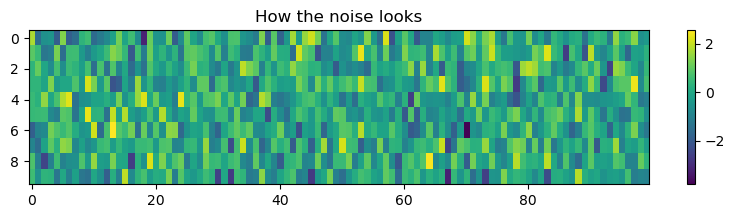

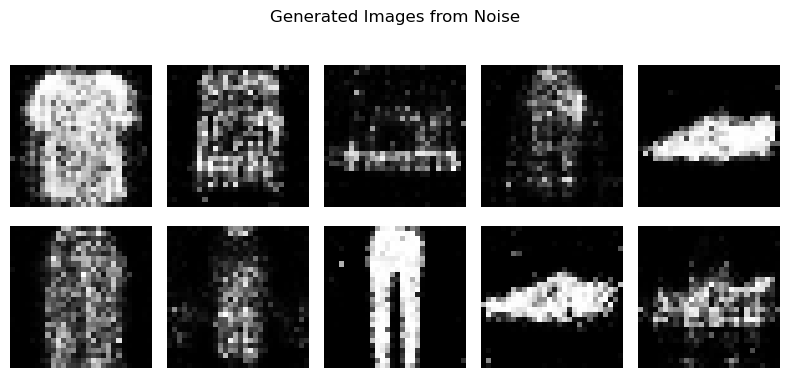


Epoch 22/30
Generator loss: 0.8830, Discriminator loss: 1.2568

Epoch 23/30
Generator loss: 0.8726, Discriminator loss: 1.3248

Epoch 24/30
Generator loss: 0.8970, Discriminator loss: 1.3509

Epoch 25/30
Generator loss: 0.8829, Discriminator loss: 1.3399

Epoch 26/30
Generator loss: 0.8763, Discriminator loss: 1.2799

Epoch 27/30
Generator loss: 0.8960, Discriminator loss: 1.3251

Epoch 28/30
Generator loss: 0.9065, Discriminator loss: 1.2866

Epoch 29/30
Generator loss: 0.8514, Discriminator loss: 1.3610

Epoch 30/30
Generator loss: 0.8511, Discriminator loss: 1.2882

Training complete


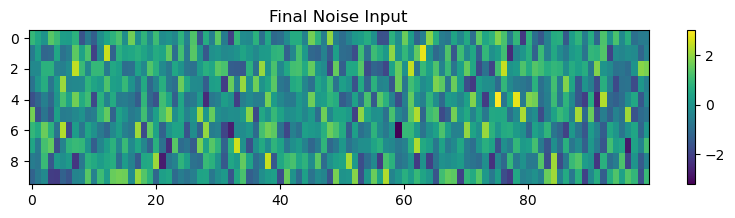

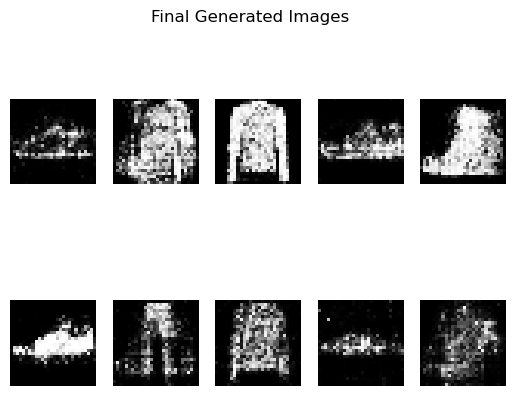

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

# -----------------------------
# Load dataset
# -----------------------------
(train_x, _), (_, _) = fashion_mnist.load_data()

# Normalize to [-1, 1]
train_x = (train_x / 255.0) * 2 - 1
train_x = train_x.reshape(-1, 28, 28, 1).astype("float32")

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(train_x)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# -----------------------------
# Generator
# -----------------------------
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(512),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),

        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),

        layers.Dense(784, activation='tanh'),
        layers.Reshape((28, 28, 1))
    ])
    return model

# -----------------------------
# Discriminator
# -----------------------------
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.5),

        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.5),

        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

# -----------------------------
# Loss + Optimizers
# -----------------------------
cross_entropy = tf.keras.losses.BinaryCrossentropy()

gen_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

# -----------------------------
# Training Step
# -----------------------------
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Generator loss
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

        # Discriminator loss with label smoothing
        real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

        disc_loss = real_loss + fake_loss

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

# -----------------------------
# Training Loop
# -----------------------------
EPOCHS = 30

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for image_batch in dataset:
        g_loss, d_loss = train_step(image_batch)

    print(f"Generator loss: {g_loss:.4f}, Discriminator loss: {d_loss:.4f}")

    # -----------------------------
    # Visualization every 10 epochs
    # -----------------------------
    if epoch % 10 == 0:
        noise = tf.random.normal([10, 100])
        generated = generator(noise, training=False)

        # ----------- SHOW NOISE -----------
        plt.figure(figsize=(10, 2))
        plt.imshow(noise.numpy(), cmap='viridis', aspect='auto')
        plt.title("How the noise looks")
        plt.colorbar()
        plt.show()

        # ----------- SHOW GENERATED IMAGES -----------
        plt.figure(figsize=(8, 4))
        for i in range(10):
            plt.subplot(2, 5, i + 1)

            img = 0.5 * generated[i] + 0.5
            plt.imshow(img.numpy().reshape(28, 28), cmap='gray')
            plt.axis('off')

        plt.suptitle("Generated Images from Noise")
        plt.tight_layout()
        plt.show()

print("\nTraining complete")

# -----------------------------
# Final Generation
# -----------------------------
noise = tf.random.normal([10, 100])
generated = generator(noise, training=False)

# Show final noise
plt.figure(figsize=(10, 2))
plt.imshow(noise.numpy(), cmap='viridis', aspect='auto')
plt.title("Final Noise Input")
plt.colorbar()
plt.show()

# Show final generated images
fig, axe = plt.subplots(2, 5)
fig.suptitle("Final Generated Images")

idx = 0
for i in range(2):
    for j in range(5):
        img = 0.5 * generated[idx] + 0.5
        axe[i, j].imshow(img.numpy().reshape(28, 28), cmap='gray')
        axe[i, j].axis('off')
        idx += 1

plt.show()